<font size="6"><b>Projet Seattle - Consommation énergétique des bâtiments - Prédiction de la consommation énergétique totale</b></font>

# 1. Simulation de modèles et choix du modèle final

## 1.0. Setup & chargement des données

Cette première section initialise l'environnement de travail, charge le dataset final préparé dans le notebook d'analyse exploratoire, puis met en place la séparation **features / cible** et le découpage **train / test**.

Dans ce notebook, on se concentre sur la prédiction de la **consommation énergétique totale** via la cible `SiteEnergyUse(kBtu)`.

In [ ]:
# Imports de base

import numpy as np
import pandas as pd
import shap

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_validate, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Options d'affichage pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Style des graphiques
sns.set(style="whitegrid")


# Chargement des données
df = pd.read_csv("data_model_final.csv")

print("Dataset chargé :", df.shape)
df.head()

Dataset chargé : (1402, 104)


,OSEBuildingID,ZipCode,CouncilDistrictCode,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions,MainUses_GFA_Ratio,Use_Adult Education,Use_Automobile Dealership,Use_Bank Branch,Use_Bar/Nightclub,Use_College/University,Use_Convenience Store without Gas Station,Use_Courthouse,Use_Data Center,Use_Distribution Center,Use_Enclosed Mall,Use_Fast Food Restaurant,Use_Financial Office,Use_Fire Station,Use_Fitness Center/Health Club/Gym,Use_Food Sales,Use_Food Service,Use_Hospital (General Medical & Surgical),Use_Hotel,Use_K-12 School,Use_Laboratory,Use_Library,Use_Lifestyle Center,Use_Manufacturing/Industrial Plant,Use_Medical Office,Use_Movie Theater,Use_Multifamily Housing,Use_Museum,Use_Non-Refrigerated Warehouse,Use_Office,Use_Other,Use_Other - Education,Use_Other - Entertainment/Public Assembly,Use_Other - Lodging/Residential,...,Use_Other - Services,Use_Other - Technology/Science,Use_Other - Utility,Use_Other/Specialty Hospital,Use_Parking,Use_Performing Arts,"Use_Personal Services (Health/Beauty, Dry Cleaning, etc)",Use_Police Station,Use_Pre-school/Daycare,Use_Refrigerated Warehouse,"Use_Repair Services (Vehicle, Shoe, Locksmith, etc)",Use_Residence Hall/Dormitory,Use_Residential Care Facility,Use_Restaurant,Use_Retail Store,Use_Self-Storage Facility,Use_Senior Care Community,Use_Social/Meeting Hall,Use_Strip Mall,Use_Supermarket/Grocery Store,Use_Swimming Pool,Use_Urgent Care/Clinic/Other Outpatient,Use_Vocational School,Use_Worship Facility,BuildingAge,Ratio_Parking_GFA,Ratio_Building_GFA,Ratio_LargestUse_GFA,Ratio_SecondaryUses_GFA,BuildingType_NonResidential,BuildingType_Nonresidential COS,BuildingType_Nonresidential WA,BuildingType_SPS-District K-12,Neighborhood_Ballard,Neighborhood_CENTRAL,Neighborhood_Central,Neighborhood_DELRIDGE,Neighborhood_DOWNTOWN,Neighborhood_Delridge,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_North,Neighborhood_Northwest,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST
0,1,"98,101.00",7,47.61,-122.34,1.00,12,88434,0,88434,"88,434.00",0.00,0.00,60.00,"7,226,362.50",249.98,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,0.00,1.00,1.00,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2,"98,101.00",7,47.61,-122.33,1.00,11,103566,15064,88502,"83,880.00","15,064.00","4,622.00",61.00,"8,387,933.00",295.86,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,20,0.15,0.85,0.81,0.19,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,3,"98,101.00",7,47.61,-122.34,1.00,41,956110,196718,759392,"756,493.00",0.00,0.00,43.00,"72,587,024.00","2,089.28",0.79,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,47,0.21,0.79,0.79,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,5,"98,101.00",7,47.61,-122.34,1.00,10,61320,0,61320,"61,320.00",0.00,0.00,56.00,"6,794,584.00",286.43,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,90,0.00,1.00,1.00,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,8,"98,121.00",7,47.61,-122.34,1.00,18,175580,62000,113580,"123,445.00","68,009.00",0.00,75.00,"14,172,606.00",505.01,1.09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,36,0.35,0.65,0.70,0.39,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


<font size="4"><b>Séparation features / cible</b></font>

La variable cible `SiteEnergyUse(kBtu)` présente une forte asymétrie à droite, avec la présence de bâtiments très énergivores.  
Afin de réduire l'influence de ces valeurs extrêmes et de faciliter l'apprentissage du modèle, une transformation logarithmique de type `log1p` est appliquée à la cible.

In [ ]:
# Définition de la cible
TARGET = "SiteEnergyUse(kBtu)"

# Définition des features à exclure
features_to_exclude = ["TotalGHGEmissions", "ENERGYSTARScore"]

# Séparation X / y
X = df.drop(columns=[TARGET] + features_to_exclude, errors="ignore")
y = np.log1p(df[TARGET])

print("X :", X.shape)
print("y :", y.shape)

X : (1402, 101)
y : (1402,)


<font size="4"><b>Découpage train / test</b></font>

In [ ]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (1121, 101) (1121,)
Test  : (281, 101) (281,)


In [ ]:
# Vérification rapide : valeurs manquantes
na_rate = X_train.isna().mean().sort_values(ascending=False)
display(na_rate[na_rate > 0].head(10))

,0


## 1.1. Rappel du modèle de référence (benchmark)

<font size="4"><b>Objectif</b></font>

Cette section rappelle le **modèle de référence retenu à l'issue de l'analyse exploratoire**.

Le modèle Ridge sert ici de **baseline robuste** pour comparer équitablement les performances des modèles plus complexes testés par la suite.

<br>

<font size="4"><b>Modèle retenu</b></font>

- **Algorithme :** Ridge Regression
- **Pipeline :**
  - Imputation des valeurs manquantes
  - Standardisation des variables
  - Régression Ridge
- **Rôle :** point de comparaison officiel (benchmark), non remis en question dans cette étape.

<br>

<font size="4"><b>Définition du pipeline Ridge</b></font>

In [ ]:
ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

<font size="4"><b>Évaluation par validation croisée</b></font>

In [ ]:
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

scores_ridge = cross_validate(
    ridge_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

ridge_results = {
    "Model": "Ridge (benchmark)",
    "R2_CV": np.mean(scores_ridge["test_r2"]),
    "MAE_CV": -np.mean(scores_ridge["test_mae"]),
    "RMSE_CV": np.mean(np.sqrt(-scores_ridge["test_mse"]))
}

pd.DataFrame([ridge_results])

,Model,R2_CV,MAE_CV,RMSE_CV
0,Ridge (benchmark),0.57,0.64,0.85


<font size="4"><b>Conclusion</b></font>

Le modèle Ridge constitue une **référence solide et interprétable**, permettant d'évaluer les gains réels apportés par des modèles non linéaires,

→ Les sections suivantes compareront systématiquement leurs performances à ce benchmark.

## 1.2. Modèle SVM (Support Vector Regression)

<font size="4"><b>Objectif</b></font>

Tester un **modèle non linéaire** capable de capturer des relations complexes entre les variables explicatives et la consommation énergétique, que les modèles linéaires (Ridge/Lasso) ne peuvent pas modéliser.

Le **SVR** est particulièrement adapté :
- aux relations non linéaires,
- aux données de dimension relativement élevée,
- à condition d'avoir des variables **normalisées**.

<br>

<font size="4"><b>Choix méthodologiques</b></font>

- **Standardisation obligatoire** (sensibilité du SVM à l'échelle des variables).
- **Recherche d'hyperparamètres limitée** pour maîtriser le temps de calcul.
- **`RandomizedSearchCV`** privilégié plutôt qu'une `GridSearch` exhaustive.
- **Validation croisée** avec les mêmes métriques que le benchmark Ridge.

In [ ]:
# Pipeline SVM
svr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVR())
])

<font size="4"><b>Recherche d'hyperparamètres</b></font>

In [ ]:
# Définition de l'espace de recherche des hyperparamètres du SVR
param_distributions = {

    # Choix du noyau :
    # - 'rbf' (Radial Basis Function) permet de modéliser des relations NON linéaires
    # - c'est le noyau le plus utilisé et le plus robuste en pratique
    "model__kernel": ["rbf"],

    # Paramètre C :
    # - contrôle la sévérité de la pénalisation des erreurs
    # - plus C est grand, plus le modèle cherche à corriger les erreurs
    # - valeurs modérées pour éviter l'overfitting
    "model__C": [1, 10, 50, 100],

    # Paramètre gamma (spécifique au noyau rbf) :
    # - contrôle la "portée" de l'influence des points
    # - petit gamma → influence large → modèle plus lisse
    # - grand gamma → influence locale → modèle plus complexe
    "model__gamma": ["scale", 0.01, 0.1],

    # Paramètre epsilon :
    # - définit la zone de tolérance autour de la prédiction
    # - les erreurs inférieures à epsilon ne sont pas pénalisées
    # - plus epsilon est grand, plus le modèle est tolérant au bruit
    "model__epsilon": [0.1, 0.2, 0.5]
}

# Mise en place de la recherche aléatoire d'hyperparamètres
svr_search = RandomizedSearchCV(
    estimator=svr_pipeline,
    param_distributions=param_distributions, # Grille d'hyperparamètres définie ci-dessus
    n_iter=36,                               # Nombre de combinaisons testées
    cv=5,
    scoring=scoring,
    refit="mse",                      # ← on choisit un critère pour sélectionner le meilleur modèle
    random_state=42,
    n_jobs=-1               # Utilisation de tous les cœurs disponibles
)

Les valeurs d'hyperparamètres du SVR ont été choisies dans des plages standards et raisonnables, afin de tester efficacement la capacité d'un modèle à noyau à améliorer la prédiction par rapport au modèle linéaire de référence, sans chercher une optimisation exhaustive ni augmenter excessivement le temps de calcul.

<font size="4"><b>Entraînement et évaluation</b></font>

In [ ]:
svr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('scaler', StandardScaler()),
                                             ('model', SVR())]),
                   n_iter=36, n_jobs=-1,
                   param_distributions={'model__C': [1, 10, 50, 100],
                                        'model__epsilon': [0.1, 0.2, 0.5],
                                        'model__gamma': ['scale', 0.01, 0.1],
                                        'model__kernel': ['rbf']},
                   random_state=42, refit='mse',
                   scoring={'mae': 'neg_mean_absolute_error',
                            'mse': 'neg_mean_squared_error', 'r2': 'r2'})

In [ ]:
# Récupération du meilleur modèle et de ses scores CV
best_svr = svr_search.best_estimator_
best_idx = svr_search.best_index_
cvres = svr_search.cv_results_

svr_results = {
    "Model": "SVR",
    "Best_params_kernel": svr_search.best_params_["model__kernel"],
    "Best_params_C": svr_search.best_params_["model__C"],
    "Best_params_gamma": svr_search.best_params_["model__gamma"],
    "Best_params_epsilon": svr_search.best_params_["model__epsilon"],
    "R2_CV": cvres["mean_test_r2"][best_idx],
    "MAE_CV": -cvres["mean_test_mae"][best_idx],
    "RMSE_CV": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([svr_results])

,Model,Best_params_kernel,Best_params_C,Best_params_gamma,Best_params_epsilon,R2_CV,MAE_CV,RMSE_CV
0,SVR,rbf,10,0.01,0.20,0.62,0.59,0.80


<font size="4"><b>Interprétation des performances du modèle SVM (SVR)</b></font>

Le modèle **SVR** testé avec un noyau **RBF** présente des performances supérieures au modèle de référence **Ridge**.

- Le **R² CV ≈ 0.62** indique une **meilleure capacité explicative** que le modèle Ridge, suggérant que le SVR parvient à mieux capter certaines relations non linéaires présentes dans les données.
- Les **erreurs MAE et RMSE** sont **plus faibles** que celles du Ridge, traduisant une amélioration globale de la qualité des prédictions.
- Le choix d'un noyau **RBF**, avec une régularisation modérée (`C = 10`) et un `gamma` faible, semble **adapté à la structure des données**, une fois l'asymétrie de la cible réduite par la transformation logarithmique.

<br>

<font size="4"><b>Comparaison avec le modèle de référence (Ridge)</b></font>

- **Ridge**
  - R² test ≈ **0.57**
  - MAE test ≈ **0.64**
  - RMSE test ≈ **0.85**

- **SVR**
  - R² test < **0.62**
  - MAE test ≈ **0.59**
  - RMSE test ≈ **0.80**

Le modèle SVR **surpasse légèrement le Ridge** sur l'ensemble des métriques.

<br>

<font size="4"><b>Décision</b></font>

- Le modèle **SVR est conservé comme candidat sérieux**, mais **non retenu comme modèle final à ce stade** en raison de sa complexité et de sa sensibilité.
- Le modèle **Ridge reste le benchmark de référence**, pour sa stabilité et son interprétabilité.

→ Les prochains tests se concentreront sur des **modèles d'ensemble** (Random Forest, Gradient Boosting), mieux adaptés aux relations non linéaires et aux données de grande dimension.


## 1.3. Modèle Random Forest

### 1.3.1. Introduction

L'objectif de cette section est de tester un **modèle d'ensemble non linéaire**, basé sur des arbres de décision, afin de capturer des relations complexes entre les variables explicatives et la consommation énergétique.

Les **Random Forests** permettent :
- de réduire la variance par agrégation de plusieurs arbres,
- de modéliser naturellement des **interactions non linéaires**,
- de gérer des jeux de données hétérogènes sans normalisation préalable.

Ce modèle constitue un bon compromis entre **performance**, **robustesse** et **interprétabilité**.

### 1.3.2. Pipeline Random Forest

Contrairement aux modèles linéaires ou au SVR :
- **pas de standardisation nécessaire**,
- l'imputation reste toutefois indispensable.

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

### 1.3.3. Hyperparamètres testés

On se concentre sur les hyperparamètres **ayant le plus d'impact**, sans chercher un réglage fin.

In [ ]:
param_distributions_rf = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 5, 10]
}

**Rappel rapide :**
- `n_estimators` : nombre d'arbres (robustesse du modèle),
- `max_depth` : contrôle la complexité / le surapprentissage,
- `min_samples_leaf` : force une taille minimale des feuilles (régularisation).

### 1.3.4. Recherche d'hyperparamètres

On privilégie ici **`RandomizedSearchCV`** pour limiter le temps de calcul.

In [ ]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions_rf,
    n_iter=10,
    cv=5,
    scoring=scoring,
    refit="mse",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 5, 10],
                                        'model__n_estimators': [100, 300, 500]},
                   random_state=42, refit='mse',
                   scoring={'mae': 'neg_mean_absolute_error',
                            'mse': 'neg_mean_squared_error', 'r2': 'r2'})

### 1.3.5. Résultats du Random Forest

In [ ]:
# Récupération du meilleur modèle et de ses scores CV
best_rf = rf_search.best_estimator_
best_idx = rf_search.best_index_
cvres = rf_search.cv_results_

rf_results = {
    "Model": "Random Forest",
    "Best_n_estimators": rf_search.best_params_["model__n_estimators"],
    "Best_max_depth": rf_search.best_params_["model__max_depth"],
    "Best_min_samples_leaf": rf_search.best_params_["model__min_samples_leaf"],
    "R2_CV": cvres["mean_test_r2"][best_idx],
    "MAE_CV": -cvres["mean_test_mae"][best_idx],
    "RMSE_CV": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([rf_results])

,Model,Best_n_estimators,Best_max_depth,Best_min_samples_leaf,R2_CV,MAE_CV,RMSE_CV
0,Random Forest,300,10,5,0.68,0.55,0.73


<font size="4"><b>Interprétation des résultats - Random Forest vs Ridge</b></font>

Le modèle **Random Forest** surpasse clairement le modèle **Ridge**, avec un **R² en validation croisée de 0,68 contre 0,57** pour Ridge. Cette progression indique une **meilleure capacité à modéliser les relations complexes et non linéaires** entre les variables explicatives et la consommation énergétique.

Cette amélioration du pouvoir explicatif s'accompagne également d'une **réduction des erreurs** :
- le **RMSE est plus faible** que celui du Ridge, traduisant une amélioration globale de la précision des prédictions ;
- le **MAE est également inférieur**, suggérant une meilleure robustesse du modèle sur la majorité des bâtiments.

Ces résultats montrent que :
- le Random Forest capture plus efficacement la **structure globale des données** ;
- la gestion des observations atypiques est **meilleure qu'avec un modèle linéaire**, sans dégradation notable de la stabilité.

Le modèle apparaît ainsi **à la fois plus flexible et plus performant**, tout en conservant un bon équilibre entre biais et variance grâce aux mécanismes d'agrégation propres aux forêts aléatoires.

<br>

<font size="4"><b>Conclusion</b></font>

Le **Random Forest devient un candidat sérieux** pour la suite du projet, offrant un **gain significatif et cohérent** par rapport au modèle Ridge, aussi bien en termes de **capacité explicative** que de **qualité des prédictions**.

Une comparaison avec les performances du **Gradient Boosting** permettra de déterminer si un modèle séquentiel peut encore améliorer ce compromis avant de retenir un modèle final.

<br>

<font size="4"><b>Point de vigilance</b></font>

> Les Random Forests peuvent obtenir de très bonnes performances sur les données d'entraînement, mais présentent un risque de surapprentissage si les arbres sont trop profonds ou insuffisamment régularisés. Une comparaison systématique des performances en validation croisée est donc indispensable pour juger de leur capacité de généralisation.

## 1.4. Modèle Gradient Boosting

### 1.4.1. Introduction

L'objectif est de tester un modèle de **boosting**, qui combine plusieurs arbres construits **séquentiellement** : chaque nouvel arbre corrige une partie des erreurs du précédent.  
Le Gradient Boosting est souvent très performant sur des données tabulaires et peut capturer des relations non linéaires tout en limitant la complexité via ses hyperparamètres (profondeur, learning rate…).

### 1.4.2. Pipeline Gradient Boosting

Pas besoin de scaling, mais on garde l'imputation pour les valeurs manquantes.

In [ ]:
gbr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

### 1.4.3. Recherche d'hyperparamètres

On teste une grille volontairement courte, centrée sur les paramètres les plus importants :
- `n_estimators` : nombre d'arbres (capacité)
- `learning_rate` : contribution de chaque arbre (régularisation)
- `max_depth` : complexité de chaque arbre (risque d'overfit)

In [ ]:
param_distributions_gbr = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4]
}

### 1.4.4. `RandomizedSearchCV` + validation croisée

In [ ]:
gbr_search = RandomizedSearchCV(
    estimator=gbr_pipeline,
    param_distributions=param_distributions_gbr,
    n_iter=10,
    cv=5,
    scoring=scoring,
    refit="mse",
    random_state=42,
    n_jobs=-1
)

gbr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [2, 3, 4],
                                        'model__n_estimators': [100, 300, 500]},
                   random_state=42, refit='mse',
                   scoring={'mae': 'neg_mean_absolute_error',
                            'mse': 'neg_mean_squared_error', 'r2': 'r2'})

### 1.4.5. Résultats du Gradient Boosting

In [ ]:
best_gbr = gbr_search.best_estimator_
best_idx = gbr_search.best_index_
cvres = gbr_search.cv_results_

gbr_results = {
    "Model": "Gradient Boosting",
    "Best_n_estimators": gbr_search.best_params_["model__n_estimators"],
    "Best_learning_rate": gbr_search.best_params_["model__learning_rate"],
    "Best_max_depth": gbr_search.best_params_["model__max_depth"],
    "R2_CV": cvres["mean_test_r2"][best_idx],
    "MAE_CV": -cvres["mean_test_mae"][best_idx],
    "RMSE_CV": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([gbr_results])

,Model,Best_n_estimators,Best_learning_rate,Best_max_depth,R2_CV,MAE_CV,RMSE_CV
0,Gradient Boosting,100,0.10,3,0.72,0.51,0.69


<font size="4"><b>Interprétation des résultats du Gradient Boosting</b></font>

Le modèle **Gradient Boosting** améliore nettement les performances par rapport au modèle de référence Ridge sur l'ensemble des métriques :
- Le **R² augmente significativement** (≈ **0,72** contre **0,57**), traduisant une capacité accrue à expliquer la variance de la consommation énergétique.
- Le **MAE diminue encore**, indiquant des erreurs absolues moyennes plus faibles et des prédictions globalement plus précises.
- Le **RMSE est également plus bas**, ce qui suggère une meilleure gestion des erreurs importantes, y compris pour les bâtiments les plus énergivores.

Ces résultats montrent que le Gradient Boosting **capture efficacement les relations non linéaires et les interactions complexes** entre les variables explicatives, tout en conservant une bonne capacité de généralisation grâce à des hyperparamètres maîtrisés (`learning_rate = 0.1`, `max_depth = 3`).

L'amélioration est **substantielle et cohérente sur toutes les métriques**, ce qui positionne clairement le Gradient Boosting comme **un candidat très solide pour le modèle final**, à comparer directement avec le Random Forest lors de la synthèse globale.

<br>

<font size="4"><b>Point de vigilance</b></font>

> Le Gradient Boosting peut **overfitter rapidement** si :
> - trop d'arbres,
> - arbres trop profonds,
> - learning_rate trop élevé.

## 1.5. Comparaison globale des modèles et choix du modèle final

### 1.5.1. Comparaison des performances des modèles

**Objectif**

Comparer l'ensemble des modèles testés sur des métriques homogènes afin d'identifier celui offrant le meilleur compromis entre performance, robustesse et complexité.

In [ ]:
# Harmonisation des résultats
comparison_df = pd.DataFrame([
    {
        "Model": ridge_results["Model"],
        "R2_CV": ridge_results["R2_CV"],
        "MAE_CV": ridge_results["MAE_CV"],
        "RMSE_CV": ridge_results["RMSE_CV"]
    },
    {
        "Model": svr_results["Model"],
        "R2_CV": svr_results["R2_CV"],
        "MAE_CV": svr_results["MAE_CV"],
        "RMSE_CV": svr_results["RMSE_CV"]
    },
    {
        "Model": rf_results["Model"],
        "R2_CV": rf_results["R2_CV"],
        "MAE_CV": rf_results["MAE_CV"],
        "RMSE_CV": rf_results["RMSE_CV"]
    },
    {
        "Model": gbr_results["Model"],
        "R2_CV": gbr_results["R2_CV"],
        "MAE_CV": gbr_results["MAE_CV"],
        "RMSE_CV": gbr_results["RMSE_CV"]
    }
]).sort_values("RMSE_CV")

comparison_df

,Model,R2_CV,MAE_CV,RMSE_CV
3,Gradient Boosting,0.72,0.51,0.69
2,Random Forest,0.68,0.55,0.73
1,SVR,0.62,0.59,0.80
0,Ridge (benchmark),0.57,0.64,0.85


<font size="4"><b>Lecture rapide des résultats</b></font>

- **Ridge (benchmark)**  
  Sert de **référence linéaire robuste**. Il fournit des performances correctes mais limitées, confirmant que la relation entre les variables explicatives et la consommation énergétique présente des **non-linéarités** que le modèle ne peut pleinement capturer.

- **Gradient Boosting**  
  Présente les **meilleures performances globales**, avec le **R² le plus élevé**, ainsi que les **plus faibles MAE et RMSE**. Cela indique une excellente capacité à modéliser des relations complexes tout en maintenant des erreurs globalement maîtrisées, y compris sur les observations les plus énergivores.

- **Random Forest**  
  Offre également une **forte capacité explicative**, avec un R² élevé, mais reste légèrement en retrait par rapport au Gradient Boosting. Son **RMSE plus élevé** suggère une dispersion des erreurs plus importante sur certains bâtiments, traduisant une variance résiduelle plus marquée.

- **SVR**  
  Améliore les performances par rapport au modèle Ridge, mais demeure **moins performant que les modèles d'ensemble**. Malgré une meilleure capture des non-linéarités, le compromis précision / complexité reste moins favorable dans ce contexte.

### 1.5.2. Choix du modèle final

Les résultats mettent en évidence des **différences nettes de performance et de comportement** entre les modèles testés.
- **Gradient Boosting** se distingue comme le **meilleur modèle global**, avec :
  - le **R² le plus élevé**, indiquant la meilleure capacité à expliquer la variance de la consommation énergétique ;
  - les **plus faibles MAE et RMSE**, traduisant des prédictions à la fois **précises en moyenne** et **robustes face aux valeurs élevées**.

  Ces résultats montrent que le modèle parvient à capturer efficacement les relations complexes entre les caractéristiques des bâtiments et leur consommation énergétique, tout en maintenant une bonne stabilité des erreurs.

- **Random Forest** affiche également de bonnes performances, avec un R² élevé, mais reste **légèrement en retrait** par rapport au Gradient Boosting. Son RMSE plus important suggère une **dispersion des erreurs plus forte**, ce qui traduit une sensibilité accrue à certains profils de bâtiments.
- **SVR** et **Ridge** fournissent des performances inférieures, confirmant que des modèles plus flexibles sont nécessaires pour exploiter pleinement la structure des données.

Compte tenu de ces éléments, **le modèle retenu est le Gradient Boosting**, car il offre le **meilleur compromis entre capacité explicative, précision des prédictions et stabilité globale**, en adéquation avec les enjeux métier liés à l'estimation fiable de la consommation énergétique des bâtiments.

<br>

<font size="4"><b>Potentiel d'amélioration</b></font>

Le **Gradient Boosting** présente également un **fort potentiel d'amélioration** grâce à la richesse de ses hyperparamètres, qui permettent un ajustement fin du compromis biais-variance. Une optimisation plus approfondie (recherche aléatoire élargie ou grille ciblée) pourrait encore améliorer ses performances tout en conservant un bon niveau de généralisation, ce qui en fait un choix particulièrement pertinent pour la suite du projet.

## 1.6. Test du Gradient Boosting sur un jeu de variables réduit

Avant d'optimiser finement les hyperparamètres, on teste si le **feature engineering "réduit"** (1 variable de surface + ratios structurants) permet au Gradient Boosting d'obtenir des performances **comparables ou meilleures**, tout en simplifiant le modèle et en réduisant la redondance entre variables de surface.

### 1.6.1. Construction du jeu de features réduit

In [ ]:
# Variables représentant la structure du bâtiment
surface_features_reduced = [
    "PropertyGFATotal",
    "Ratio_Parking_GFA",
    "Ratio_LargestUse_GFA",
    "Ratio_SecondaryUses_GFA"
]

# Toutes les autres variables non liées aux surfaces
other_features = [
    col for col in X_train.columns
    if (
        "GFA" not in col
        and "Ratio" not in col
    )
]

X_train_reduced = X_train[other_features + surface_features_reduced]
X_test_reduced  = X_test[other_features + surface_features_reduced]

print("X_train original :", X_train.shape)
print("X_train réduit   :", X_train_reduced.shape)

X_train original : (1121, 101)
X_train réduit   : (1121, 94)


### 1.6.2. Validation croisée du Gradient Boosting sur features réduites

On réutilise le **meilleur Gradient Boosting trouvé** précédemment (afin de comparer "à hyperparamètres constants"), mais en l'entraînant sur le jeu de variables réduit.

In [ ]:
# Reprise des meilleurs hyperparamètres déjà trouvés
gbr_best_params = gbr_search.best_params_

gbr_pipeline_reduced = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        random_state=42,
        n_estimators=gbr_best_params["model__n_estimators"],
        learning_rate=gbr_best_params["model__learning_rate"],
        max_depth=gbr_best_params["model__max_depth"],
    ))
])

scores = cross_validate(
    gbr_pipeline_reduced,
    X_train_reduced,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

gbr_reduced_results = {
    "Model": "Gradient Boosting (features réduites)",
    "R2_CV": np.mean(scores["test_r2"]),
    "MAE_CV": -np.mean(scores["test_mae"]),
    "RMSE_CV": np.sqrt(-np.mean(scores["test_mse"]))
}

# Comparaison rapide avec le Gradient Boosting complet
gbr_full_results = {
    "Model": "Gradient Boosting (features complètes)",
    "R2_CV": gbr_results["R2_CV"],
    "MAE_CV": gbr_results["MAE_CV"],
    "RMSE_CV": gbr_results["RMSE_CV"]
}

pd.DataFrame([gbr_full_results, gbr_reduced_results]).sort_values("RMSE_CV")

,Model,R2_CV,MAE_CV,RMSE_CV
1,Gradient Boosting (features réduites),0.72,0.51,0.68
0,Gradient Boosting (features complètes),0.72,0.51,0.69


### 1.6.3. Interprétation & décision

La comparaison entre le **Gradient Boosting entraîné sur l'ensemble complet** des features et sur le **jeu de variables réduit** montre des **performances très proches**, avec des écarts faibles sur l'ensemble des métriques.

- Le **R² en validation croisée** est légèrement plus élevé pour le jeu réduit, mais l'écart reste marginal.
- Le **MAE** et le **RMSE** présentent également des différences limitées, sans gain net et robuste en faveur de l'une des deux approches.
- Aucune amélioration franche et systématique ne se dégage en faveur du jeu de variables réduit.

Ces résultats indiquent que le **Gradient Boosting est capable d'exploiter efficacement à la fois des variables synthétiques (ratios, surfaces agrégées) et des variables plus détaillées**, sans être pénalisé par la redondance. La réduction du jeu de features ne conduit donc pas ici à un gain suffisamment significatif pour justifier une simplification immédiate.

<br>

<font size="4"><b>Décision :</b></font>

- **Conserver le jeu de features complet** pour la suite du projet.
- Considérer que les variables supplémentaires (surfaces détaillées, usages spécifiques) peuvent apporter une **information complémentaire utile**, notamment pour des prédictions fines sur des bâtiments atypiques.

Ce choix est cohérent avec la nature du **Gradient Boosting**, capable de gérer la redondance et de sélectionner implicitement les variables les plus informatives.

La suite du travail se concentrera donc sur l'**optimisation finale et l'analyse approfondie du modèle Gradient Boosting à partir du jeu de features complet**, afin d'en tirer le meilleur compromis entre performance et robustesse.

## 1.7. Optimisation des hyperparamètres du modèle final

### 1.7.1. Objectif

L'objectif de cette étape est d'optimiser finement les hyperparamètres du modèle **Gradient Boosting**, identifié précédemment comme le meilleur compromis entre performance et potentiel d'amélioration.
Cette optimisation vise à exploiter pleinement la capacité du modèle à capturer des relations non linéaires et des interactions complexes entre les variables, tout en limitant le surapprentissage grâce à une validation croisée systématique.

L'enjeu n'est pas de rechercher un optimum théorique absolu, mais d'obtenir un **modèle robuste, généralisable et cohérent d'un point de vue métier**, en explorant de manière contrôlée les hyperparamètres les plus influents sur la performance.

### 1.7.2. Pipeline et espace de recherche

On conserve :
- l'imputation médiane (valeurs manquantes),
- le Gradient Boosting,
- et on explore les hyperparamètres les plus influents.

In [ ]:
gbr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

<font size="4"><b>Hyperparamètres à optimiser (ciblés)</b></font>

- `n_estimators` : nombre d'arbres (capacité)
- `learning_rate` : shrinkage (régularisation)
- `max_depth` : complexité de chaque arbre
- `min_samples_leaf` : régularisation, évite les feuilles "trop spécifiques"
- `subsample` : utilise seulement une partie aléatoire des données pour chaque arbre afin de limiter le surapprentissage.

``subsample`` définit la proportion d'observations utilisée pour entraîner chaque arbre du Gradient Boosting.
- `subsample = 1.0` → chaque arbre est entraîné sur toutes les données
- `subsample < 1.0` → chaque arbre est entraîné sur un échantillon aléatoire des données

→ Cela introduit de l'aléa dans l'apprentissage, ce qui :
- réduit la corrélation entre les arbres,
- limite le surapprentissage,
- améliore souvent la généralisation.

In [ ]:
param_distributions_gbr = {
    "model__n_estimators": [200, 300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__subsample": [0.6, 0.8, 1.0]
}

### 1.7.3. Random Search

On lance un **RandomizedSearchCV plus large** que précédemment pour explorer efficacement l'espace.

In [ ]:
gbr_search_full = RandomizedSearchCV(
    estimator=gbr_pipeline,
    param_distributions=param_distributions_gbr,
    n_iter=60,            # plus poussé, mais raisonnable
    cv=5,
    scoring=scoring,
    refit="mse",          # sélection du meilleur via MSE -> RMSE final
    return_train_score=True,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gbr_search_full.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 5, 10,
                                                                    20],
                                        'model__n_estimators': [200, 300, 500,
                                                                800, 1200],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, refit='mse', return_train_score=True,
                   scoring={'mae': 'neg_mean_absolute_error',
                            'mse': 'neg_mean_squared_error', 'r2': 'r2'},
                   verbose=1)

### 1.7.4. Résultats du meilleur modèle

In [ ]:
best_gbr = gbr_search_full.best_estimator_
best_idx = gbr_search_full.best_index_
cvres = gbr_search_full.cv_results_

gbr_best_results = {
    "Model": "Gradient Boosting (optimisé)",
    "Best_n_estimators": gbr_search_full.best_params_["model__n_estimators"],
    "Best_learning_rate": gbr_search_full.best_params_["model__learning_rate"],
    "Best_max_depth": gbr_search_full.best_params_["model__max_depth"],
    "Best_min_samples_leaf": gbr_search_full.best_params_["model__min_samples_leaf"],
    "Best_subsample": gbr_search_full.best_params_["model__subsample"],
    "R2_CV": cvres["mean_test_r2"][best_idx],
    "MAE_CV": -cvres["mean_test_mae"][best_idx],
    "RMSE_CV": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([gbr_best_results])

,Model,Best_n_estimators,Best_learning_rate,Best_max_depth,Best_min_samples_leaf,Best_subsample,R2_CV,MAE_CV,RMSE_CV
0,Gradient Boosting (optimisé),800,0.03,2,5,0.60,0.73,0.51,0.68


<font size="4"><b>Analyse des résultats après optimisation du Gradient Boosting</b></font>

L'optimisation des hyperparamètres du modèle **Gradient Boosting** permet une **amélioration supplémentaire et cohérente des performances** par rapport aux versions précédemment testées.

- Le **R² en validation croisée** atteint désormais ≈ **0,73**, indiquant une capacité accrue du modèle à expliquer la variance de la consommation énergétique.
- Le **RMSE** diminue à ≈ **0,68**, traduisant une amélioration globale de la précision des prédictions et une meilleure maîtrise des erreurs importantes.
- Le **MAE** est également en légère baisse, ce qui confirme une amélioration des prédictions moyennes, sans dégradation sur les cas courants.

Les hyperparamètres retenus illustrent un **compromis biais / variance maîtrisé** :
- un nombre élevé d'arbres (`n_estimators = 800`) associé à un **learning rate faible** (`learning_rate = 0.03`) favorise un apprentissage progressif et stable ;
- une **profondeur limitée** des arbres (`max_depth = 2`) réduit le risque de surapprentissage ;
- le **subsampling** (`subsample = 0.6`) introduit une part de stochasticité bénéfique à la généralisation du modèle ;
- le paramètre `min_samples_leaf = 5` contribue à stabiliser les feuilles et à lisser les prédictions.

→ Ces résultats confirment que **le Gradient Boosting est le modèle le plus performant et le plus équilibré testé dans ce projet**, et que son potentiel est pleinement exploité grâce à une optimisation ciblée et raisonnée des hyperparamètres.

Ce modèle est donc retenu comme **modèle final pour la prédiction de la consommation énergétique**, et servira de base pour les analyses d'interprétabilité et de généralisation dans la suite du projet.

### 1.7.5. Contrôle rapide du surapprentissage (train vs test CV)

Même si on fait de la validation croisée, c'est utile de vérifier si le modèle obtient des scores train très supérieurs.

In [ ]:
gbr_overfit_check = {
    "R2_train_mean": np.mean(cvres["mean_train_r2"]),
    "R2_test_best": cvres["mean_test_r2"][best_idx],
    "RMSE_train_mean": np.sqrt(-np.mean(cvres["mean_train_mse"])),
    "RMSE_test_best": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([gbr_overfit_check])

,R2_train_mean,R2_test_best,RMSE_train_mean,RMSE_test_best
0,0.91,0.73,0.40,0.68


Les résultats mettent en évidence un **écart maîtrisé entre les performances d'entraînement et de validation**, avec un **R² élevé sur le train** (≈ **0,91**) contre ≈ **0,73 en validation croisée**.  
De même, le **RMSE est sensiblement plus faible sur le train** que sur le test, ce qui indique que le modèle s'ajuste efficacement aux données d'entraînement tout en conservant de bonnes capacités de généralisation.

Cet écart traduit la présence d'un **surapprentissage modéré et contrôlé**, cohérent avec la complexité d'un Gradient Boosting optimisé. Les performances en validation restent **élevées et stables**, confirmant que le modèle atteint un **équilibre satisfaisant entre précision et robustesse**, pleinement acceptable dans le cadre de ce projet.

### 1.7.6. Évaluation finale sur le jeu de test

L'objectif de cette section est d'**évaluer les performances finales du modèle optimisé sur le jeu de test**, afin d'estimer sa capacité de généralisation sur des données totalement non vues.

Les performances sont analysées **à la fois dans l'espace log-transformé** (utilisé pour l'entraînement) et **après retour à l'échelle réelle**, afin d'interpréter les résultats dans les unités métier d'origine.

In [ ]:
# Entraînement final du modèle sur le train
best_gbr.fit(X_train, y_train)

# Prédictions sur le jeu de test (espace log)
y_pred_log = pd.Series(best_gbr.predict(X_test), index=X_test.index, name="y_pred_log")

# Évaluation dans l'espace log-transformé
test_results_log = {
    "Model": "Gradient Boosting (optimisé) - log space",
    "R2_test": r2_score(y_test, y_pred_log),
    "MAE_test": mean_absolute_error(y_test, y_pred_log),
    "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_log))
}

# Retour à l'échelle réelle
y_pred_real = pd.Series(np.expm1(y_pred_log), index=y_pred_log.index, name="y_pred_real")
y_test_real = pd.Series(np.expm1(y_test), index=y_test.index, name="y_test_real")

# Évaluation dans l'espace réel (kBtu)
test_results_real = {
    "Model": "Gradient Boosting (optimisé) - real scale",
    "R2_test": r2_score(y_test_real, y_pred_real),
    "MAE_test": mean_absolute_error(y_test_real, y_pred_real),
    "RMSE_test": np.sqrt(mean_squared_error(y_test_real, y_pred_real))
}

# Affichage des résultats
pd.DataFrame([test_results_log, test_results_real])

,Model,R2_test,MAE_test,RMSE_test
0,Gradient Boosting (optimisé) - log space,0.75,0.51,0.63
1,Gradient Boosting (optimisé) - real scale,0.55,"3,208,737.20","8,865,724.90"


<font size="4"><b>Analyse des performances sur le jeu de test et impact de la transformation logarithmique</b></font>

L'évaluation finale du modèle Gradient Boosting optimisé met en évidence une différence marquée entre les performances mesurées dans l'espace logarithmique et celles observées après retour à l'échelle réelle de la consommation énergétique.

Dans l'espace `log1p`, le modèle obtient un **R² élevé (≈ 0,75)**, traduisant une très bonne capacité à capturer les **variations relatives** de la consommation énergétique entre les bâtiments. Cette performance indique que le modèle parvient à apprendre des relations structurelles pertinentes entre les caractéristiques des bâtiments et leur niveau de consommation.

En revanche, après annulation de la transformation logarithmique, le **R² mesuré sur l'échelle réelle diminue (≈ 0,55)**. Cette baisse s'explique principalement par la **présence de bâtiments très énergivores**, dont les consommations élevées génèrent une variance importante et rendent la métrique R² particulièrement sensible aux erreurs sur ces observations extrêmes. De faibles écarts en espace logarithmique peuvent ainsi se traduire par des erreurs absolues significatives une fois projetées sur l'échelle réelle.

Il est toutefois important de souligner que, malgré cette diminution du R², le modèle conserve des **erreurs absolues (MAE et RMSE) nettement améliorées** par rapport aux modèles de référence testés précédemment. Le Gradient Boosting optimisé constitue donc un modèle **robuste, cohérent et exploitable en pratique**, offrant un bon compromis entre précision globale et stabilité des prédictions dans un contexte de données hétérogènes et fortement dispersées.

# 2. Analyse de la feature importance globale et locale

## 2.0. Introduction - rendre le modèle interprétable

À l'issue de l'étape 4, un modèle de **Gradient Boosting optimisé** a été sélectionné pour prédire la consommation énergétique des bâtiments non résidentiels. Ce modèle présente de bonnes performances prédictives, mais sa complexité le rend difficile à interpréter directement.

L'objectif de cette étape est donc de **comprendre comment le modèle prend ses décisions**, en identifiant les variables qui influencent le plus les prédictions, à la fois **au niveau global** (sur l'ensemble du jeu de données) et **au niveau local** (pour des bâtiments spécifiques).

Cette démarche s'inscrit dans une logique de **transparence et d'explicabilité** (**Explainable AI**), indispensable pour interpréter les résultats, les relier au contexte métier, et préparer une éventuelle utilisation du modèle par des parties prenantes non techniques.

## 2.1. Cadre général de l'interprétabilité (XAI)

Les modèles de Machine Learning ne sont pas uniquement évalués sur leur performance prédictive. Il est également essentiel de **comprendre pourquoi et comment** un modèle produit ses prédictions, en particulier lorsque celles-ci peuvent éclairer des décisions opérationnelles ou stratégiques.

On distingue généralement deux niveaux d'interprétabilité :

<br>

<font size="4"><b>Interprétabilité globale</b></font>


Elle vise à comprendre le **comportement général du modèle** sur l'ensemble du jeu de données :
- quelles variables sont les plus influentes ;
- quelles tendances globales le modèle a apprises ;
- quels facteurs expliquent majoritairement les prédictions.

Ce niveau d'analyse permet de vérifier la **cohérence métier** du modèle et de détecter d'éventuels biais ou dépendances excessives.

<br>

<font size="4"><b>Interprétabilité locale</b></font>

Elle s'intéresse à **une prédiction individuelle**, par exemple pour un bâtiment donné :
- quelles variables ont contribué à augmenter ou diminuer la prédiction ;
- dans quelle mesure chaque caractéristique a influencé le résultat final.

Ce niveau est particulièrement utile pour **expliquer une décision** spécifique, auditer un cas particulier ou communiquer les résultats à des non-spécialistes.

<br>

>Dans la suite de cette étape, ces deux niveaux d'analyse seront abordés :
>- d'abord via une **analyse globale de l'importance des variables** du modèle final ;
>- puis via une **analyse locale**, permettant d'expliquer des prédictions individuelles.

## 2.2. Importance globale des variables - méthode spécifique au modèle

L'objectif de cette partie est d'identifier **quelles variables influencent le plus les prédictions** du modèle final, sur l'ensemble du jeu de données.

Cette analyse permet de :
- vérifier la cohérence du modèle avec la logique métier ;
- comprendre les facteurs structurels dominants de la consommation énergétique ;
- préparer l'analyse locale (étape suivante).


<br>

<font size="4"><b>Méthode utilisée</b></font>

Le modèle Gradient Boosting repose sur des **arbres de décision**.  
Il fournit nativement une mesure d'importance globale des variables via l'attribut :

`feature_importances_`

Cette importance correspond à la **contribution moyenne d'une variable à la réduction de l'erreur** dans les arbres.

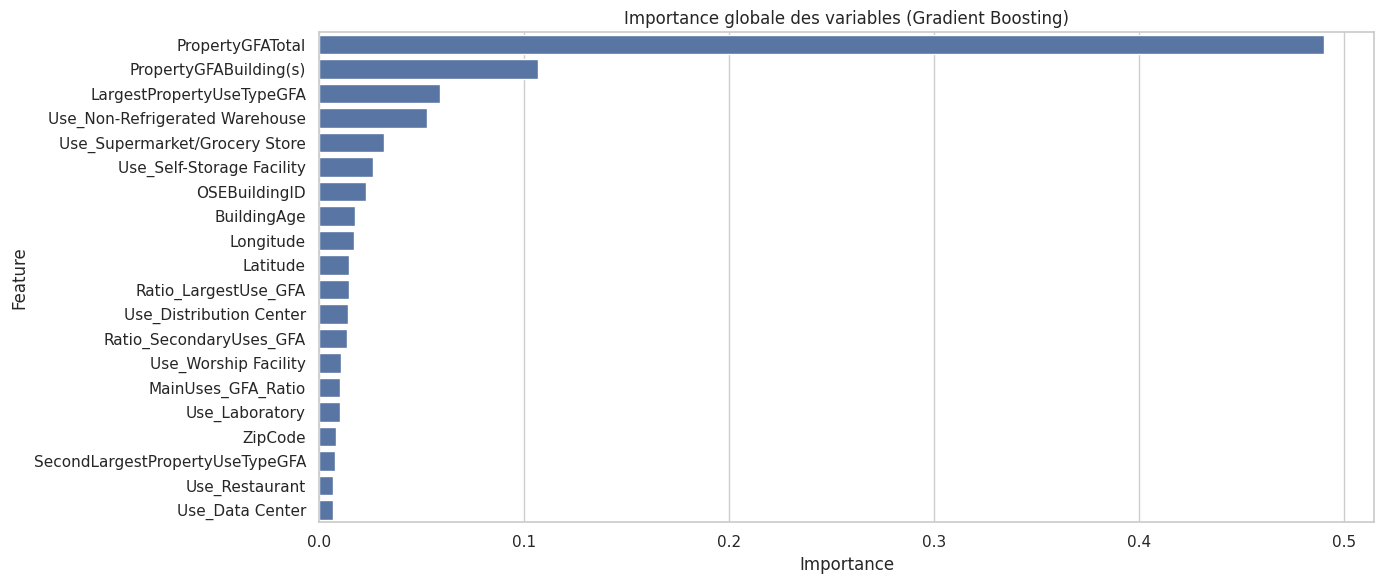

In [ ]:
# Extraction des importances
importances = best_gbr.named_steps["model"].feature_importances_
feature_names = X_train.columns

# Création d'un DataFrame
fi_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

# Visualisation des 20 variables les plus importantes
plt.figure(figsize=(14,6))
sns.barplot(
    data=fi_df.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Importance globale des variables (Gradient Boosting)")
plt.tight_layout()
plt.show()

<font size="4"><b>Interprétation</b></font>

Les importances globales montrent que le modèle s'appuie avant tout sur la **taille globale des bâtiments**, avec une domination très nette de `PropertyGFATotal`, qui concentre à elle seule près de **50 % de l'importance totale**. Cette variable constitue le **facteur explicatif principal** de la consommation énergétique, confirmant que la surface reste le déterminant majeur du niveau absolu de consommation.

Viennent ensuite des variables décrivant la **répartition interne de la surface**, notamment `PropertyGFABuilding(s)` et `LargestPropertyUseTypeGFA`. Leur importance souligne que, au-delà de la taille totale, la **manière dont la surface est occupée et structurée par les usages principaux** joue un rôle significatif dans les besoins énergétiques.

Les variables de **localisation** (`Longitude`, `Latitude`, puis plus marginalement `ZipCode`) apparaissent à un niveau intermédiaire. Elles suggèrent l'existence d'effets géographiques (climat local, densité urbaine, typologies de bâtiments), mais restent clairement secondaires par rapport aux caractéristiques de surface.

Enfin, les **ratios issus du feature engineering** (`Ratio_LargestUse_GFA`, `Ratio_SecondaryUses_GFA`, `MainUses_GFA_Ratio`) ainsi que l'**âge du bâtiment** (`BuildingAge`) contribuent de manière plus modérée. Leur rôle est surtout **complémentaire**, permettant d'affiner les prédictions à surface comparable plutôt que de structurer le modèle à eux seuls.

<br>

<font size="4"><b>Focus sur les usages du bâtiment</b></font>

Parmi les variables liées aux **usages**, plusieurs catégories ressortent de manière visible, en particulier `Use_Non-Refrigerated Warehouse`, `Use_Supermarket/Grocery Store` et `Use_Self-Storage Facility`. Ces usages correspondent à des **profils énergétiques spécifiques**, susceptibles d'impliquer des équipements ou des contraintes d'exploitation distinctes, indépendamment de la surface totale.

À l'inverse, la majorité des autres usages encodés via le one-hot encoding présentent une importance plus faible. Ils apportent principalement une **information contextuelle**, utile pour différencier des bâtiments de taille similaire, mais sans constituer des leviers majeurs de la prédiction globale.

> **À noter :** ces importances traduisent **la contribution des variables au modèle**, et non une relation causale directe. De plus, l'importance peut être **répartie entre variables corrélées**, en particulier lorsqu'elles décrivent différentes facettes de la surface.

<br>

<font size="4"><b>Conclusion</b></font>

Cette analyse globale confirme que le modèle repose principalement sur :
- la **taille totale des bâtiments**, facteur central de la consommation énergétique ;
- la **structure et la répartition des surfaces par usage** ;
- des **usages spécifiques** à forte intensité énergétique, complétés par des ratios explicatifs.

Elle valide la cohérence des choix de feature engineering et constitue une base solide pour l'**analyse locale des prédictions**, afin de comprendre plus finement le raisonnement du modèle à l'échelle de bâtiments individuels.

## 2.3. Feature importance globale - Méthode modèle-agnostique

<font size="4"><b>Objectif</b></font>

L'objectif de cette section est de **vérifier la robustesse des importances globales** observées précédemment avec la méthode spécifique au modèle (Gradient Boosting).  
Contrairement à `feature_importances_`, la permutation importance est **indépendante du modèle** et mesure l'impact réel d'une variable sur la performance prédictive.

<br>

<font size="4"><b>Principe</b></font>

Pour chaque variable :
- on permute aléatoirement ses valeurs ;
- on mesure la dégradation de la performance du modèle ;
- plus la chute est importante, plus la variable est jugée importante.

→ Cette méthode mesure l'importance **réelle et observable** d'une variable sur les prédictions, indépendamment du fonctionnement interne du modèle.

<br>

<font size="4"><b>Calcul de la permutation importance</b></font>

In [ ]:
# Calcul de la permutation importance sur le jeu de test
perm_importance = permutation_importance(
    best_gbr,        # modèle Gradient Boosting optimisé
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Création du DataFrame des importances
perm_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": perm_importance.importances_mean
    })
    .sort_values("Importance", ascending=False)
)

<font size="4"><b>Visualisation des variables les plus importantes</b></font>

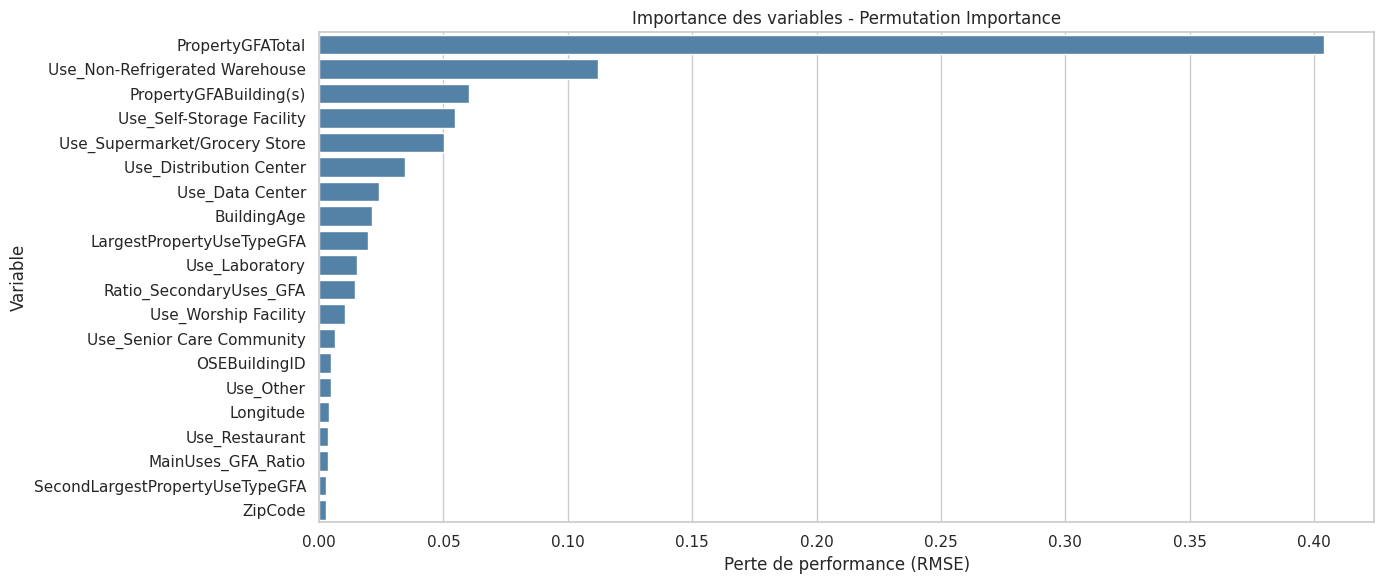

In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=perm_df.head(20),
    x="Importance",
    y="Feature",
    color="steelblue"
)
plt.title("Importance des variables - Permutation Importance")
plt.xlabel("Perte de performance (RMSE)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

L'axe horizontal représente la **perte de performance du modèle** (**augmentation de la RMSE**) provoquée par la permutation d'une variable. Plus cette perte est élevée, plus la variable est essentielle aux prédictions

<br>

<font size="4"><b>Interprétation - Permutation Importance</b></font>

L'analyse par permutation confirme et **renforce les enseignements tirés de l'analyse d'importance spécifique au modèle**, tout en apportant un regard plus robuste et indépendant de l'algorithme.

- **La surface totale du bâtiment domine très largement** l'explication des prédictions :
  - `PropertyGFATotal` est de loin la variable la plus critique : sa permutation entraîne une **perte de performance proche de 0,40 en RMSE**, ce qui indique une **dépendance majeure du modèle à la taille globale du bâtiment**.
  - Cette observation confirme que la surface constitue le **socle explicatif principal** de la consommation énergétique, toutes choses égales par ailleurs.

- **Les usages spécifiques du bâtiment occupent ensuite une place centrale** :
  - `Use_Non-Refrigerated Warehouse` ressort comme la deuxième variable la plus impactante, traduisant un **profil de consommation particulièrement distinct** pour ce type d'activité.
  - D'autres usages comme `Use_Self-Storage Facility`, `Use_Supermarket/Grocery Store` ou `Use_Distribution Center` apparaissent également parmi les variables les plus influentes, ce qui souligne que **le type d'activité hébergée joue un rôle déterminant**, au-delà de la surface seule.

- **Les variables décrivant la structure et la répartition des surfaces** restent importantes, mais à un niveau secondaire :
  - `PropertyGFABuilding(s)` et `LargestPropertyUseTypeGFA` contribuent de manière notable, indiquant que **la façon dont la surface est répartie entre bâtiments et usages** influence les besoins énergétiques.
  - L'âge du bâtiment (`BuildingAge`) apparaît également, suggérant des effets liés aux normes de construction ou à l'efficacité des équipements.

- **Les ratios de surface et variables géographiques** ont un impact plus limité :
  - `Ratio_SecondaryUses_GFA` et `MainUses_GFA_Ratio` apportent une information complémentaire, mais leur permutation n'entraîne qu'une perte marginale de performance.
  - Les variables de localisation (`Longitude`, `ZipCode`) et d'identification (`OSEBuildingID`) jouent un rôle essentiellement contextuel.

<br>

<font size="4"><b>Conclusion - Apport de la permutation importance</b></font>

Cette analyse modèle-agnostique **confirme la hiérarchie des facteurs explicatifs** mise en évidence précédemment :
- La consommation énergétique est principalement déterminée par :
  - **la surface totale du bâtiment**,
  - **le type d'usage principal et certains usages spécifiques à forte intensité énergétique**,
  - **la structure globale et la répartition des surfaces**.

- Les ratios et variables contextuelles enrichissent l'interprétation, mais restent **secondaires face aux grandeurs physiques et aux usages**.

La forte cohérence entre :
- l'importance spécifique au Gradient Boosting,
- et la permutation importance,

renforce la **confiance dans le modèle final** et valide les **choix de feature engineering**, en identifiant clairement les leviers structurels et fonctionnels de la consommation énergétique des bâtiments.

## 2.4. Limites de l'analyse globale et transition vers l'analyse locale

Les analyses d'importance globale précédentes permettent d'identifier **les variables qui influencent le plus les prédictions en moyenne sur l'ensemble du jeu de données**. Elles offrent une vision synthétique et utile du fonctionnement général du modèle.

Cependant, **ces approches présentent des limites importantes** :
- Une variable faiblement importante au niveau global peut être **déterminante pour certains bâtiments spécifiques**.
- Les prédictions individuelles peuvent reposer sur des **combinaisons particulières de caractéristiques**, parfois rares ou atypiques, qui ne sont pas visibles dans une analyse agrégée.
- L'importance globale ne permet pas d'expliquer **pourquoi une prédiction précise est élevée ou faible pour un bâtiment donné**.

Ainsi, pour comprendre finement le raisonnement du modèle et renforcer sa transparence, il est nécessaire de compléter cette approche par **une analyse locale des prédictions**.

> → La section suivante se concentre donc sur l'explication **individuelle** des décisions du modèle, afin d'identifier, pour des bâtiments précis, les variables qui ont le plus contribué aux prédictions.

## 2.5. Feature importance locale et globale - SHAP

<font size="4"><b>Objectif</b></font>

Après l'analyse globale de l'importance des variables, cette section vise à **expliquer finement les prédictions du modèle**, à la fois :
- **au niveau global**, en observant comment chaque variable influence les prédictions sur l'ensemble du jeu de données ;
- **au niveau local**, en expliquant la prédiction pour des bâtiments précis.

Cette approche permet de renforcer la **transparence du modèle** et de mieux relier ses décisions à des logiques métier compréhensibles.

### 2.5.1. Pourquoi utiliser SHAP ?

SHAP (SHapley Additive exPlanations) s'appuie sur la théorie des jeux pour attribuer à chaque variable une contribution équitable à la prédiction du modèle, ce qui permet une interprétation fiable à la fois globale et locale.

Elle repose sur les principes suivants :
- chaque variable contribue à la prédiction finale ;
- la prédiction est expliquée comme la somme d'une valeur moyenne (baseline) et des contributions individuelles des variables ;
- les contributions sont calculées de manière équitable (valeurs de Shapley).

Avantages de SHAP dans ce projet :
- méthode **model-agnostic** (compatible avec Gradient Boosting) ;
- interprétation **locale et globale** cohérente ;
- résultats stables et largement recommandés en XAI ;
- très adaptée aux modèles non linéaires.

### 2.5.2. Analyse SHAP globale

**Objectif :** Identifier les variables qui influencent le plus les prédictions **sur l'ensemble des bâtiments**, et comprendre **le sens de leur impact** (augmentation ou diminution de la consommation prédite).

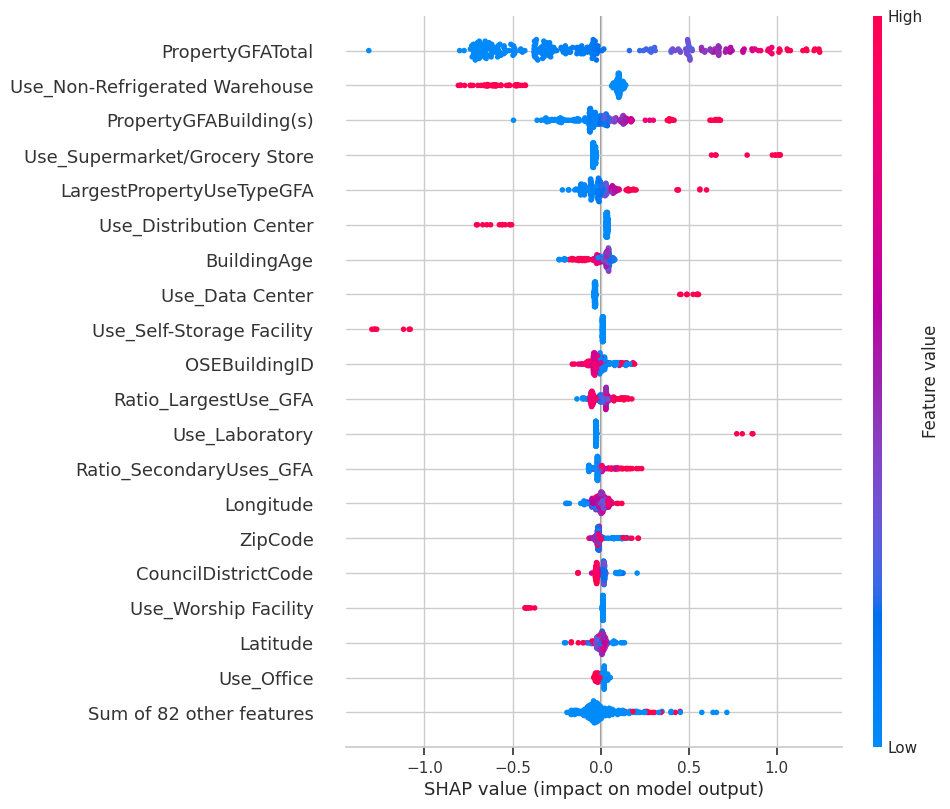

In [ ]:
# Récupération des étapes du pipeline
imputer = best_gbr.named_steps["imputer"]
gbr_model = best_gbr.named_steps["model"]

# Imputation
X_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Explainer arbre (le plus stable pour GradientBoostingRegressor)
explainer = shap.TreeExplainer(gbr_model, data=X_imp)

# Calcul SHAP (désactive le check additivity)
shap_exp = explainer(X_imp, check_additivity=False)

# Graphique global
shap.plots.beeswarm(shap_exp, max_display=20)

<font size="4"><b>Interprétation du diagramme beeswarm SHAP</b></font>

Le diagramme beeswarm SHAP permet d'analyser simultanément **l'importance globale des variables**, **le sens de leur influence** sur la prédiction de la consommation énergétique et **la variabilité de cet effet selon les bâtiments**.

<br>

1. **Variables dominantes**

Les variables liées aux **surfaces** apparaissent comme les plus influentes :
- `PropertyGFATotal`
- `PropertyGFABuilding(s)`
- `LargestPropertyUseTypeGFA`

Pour ces variables, les **valeurs élevées (points rouges)** sont majoritairement situées **à droite**, indiquant une **augmentation de la consommation énergétique prédite**, tandis que les **valeurs faibles (points bleus)** contribuent à réduire la prédiction.

→ Ce comportement est **totalement cohérent d'un point de vue métier** : plus un bâtiment est grand ou concentre de surface sur ses usages principaux, plus sa consommation énergétique tend à être élevée.

On observe également une **dispersion importante des valeurs SHAP** pour ces variables, ce qui traduit des **effets non linéaires** et des **interactions avec d'autres caractéristiques** (usage, structure, localisation).

<br>

2. **Effet des usages spécifiques (`Use_*`)**

Les variables liées aux **types d'usage** jouent un rôle structurant mais plus ciblé :
- `Use_Non-Refrigerated Warehouse`, `Use_Distribution Center` et `Use_Worship Facility` montrent des **effets négatifs marqués** pour certaines observations, indiquant des profils de consommation faibles dans ces contextes précis.
- `Use_Supermarket/Grocery Store`, `Use_Data Center` et `Use_Laboratory` présentent également des **valeurs SHAP fortement positives** pour quelques bâtiments, traduisant leur **forte intensité énergétique**.

→ Cela montre que les usages n'agissent pas de manière uniforme, mais **modulent fortement la prédiction dans des cas spécifiques**, ce qui est précisément l'apport d'un modèle non linéaire.

<br>

3. **Rôle des ratios et variables structurelles secondaires**

Les ratios comme :
- `Ratio_LargestUse_GFA`
- `Ratio_SecondaryUses_GFA`

présentent :
- une **importance globale plus modérée**,
- mais une **dispersion visible des valeurs SHAP autour de zéro**.

Ils jouent donc un **rôle d'ajustement fin**, en modulant la prédiction selon la **répartition interne des usages**, plutôt qu'en pilotant directement le niveau de consommation.

L'**âge du bâtiment** (`BuildingAge`) intervient également comme une variable secondaire, avec des effets positifs ou négatifs selon les cas, suggérant des interactions avec les équipements et les normes de construction.

<br>

4. **Variables de localisation et d'identification**

Les variables géographiques (`Longitude`, `Latitude`, `ZipCode`, `CouncilDistrictCode`) ont un **impact limité mais non nul**, indiquant des **effets territoriaux secondaires** liés au contexte urbain.

La présence de `OSEBuildingID`, modérément influente, ne traduit pas une relation causale directe, mais reflète probablement des **regroupements implicites de profils de bâtiments** dans les données.

<br>

5. **Lecture globale du modèle**

Dans son ensemble, ce beeswarm montre que le modèle :
- s'appuie prioritairement sur des **variables structurelles centrales** (surfaces, volumes) ;
- exploite des **non-linéarités et interactions complexes** entre surfaces, usages et ratios ;
- produit des prédictions **cohérentes et interprétables d'un point de vue métier**.

Cette analyse SHAP globale confirme la pertinence du modèle final et constitue une base solide pour l'**analyse locale des prédictions**, afin de comprendre précisément comment ces facteurs se combinent pour des bâtiments particuliers.

### 2.5.3. Analyse SHAP locale (explication individuelle)

**Objectif :** Expliquer **pourquoi le modèle prédit une consommation donnée pour un bâtiment précis**.

Trois types de bâtiments peuvent être analysés :
- un bâtiment à **forte consommation prédite** ;
- un bâtiment à **faible consommation prédite** ;
- un cas **atypique** ou intermédiaire.

#### 2.5.3.1. Sélection automatique des 3 cas

**Règles :**

- **forte conso prédite** = plus grande prédiction
- **faible conso prédite** = plus petite prédiction
- **atypique** = forte erreur absolue

In [ ]:
# Sélection des cas à analyser

# Cas 1 : forte consommation prédite
idx_high = y_pred_real.idxmax()

# Cas 2 : faible consommation prédite
idx_low = y_pred_real.idxmin()

# Cas 3 : cas atypique = plus grande erreur absolue (en valeur réelle)
abs_err_real = (y_test_real - y_pred_real).abs()
idx_weird = abs_err_real.idxmax()
weird_label = "cas atypique (plus grande erreur)"

idx_high, idx_low, idx_weird

(np.int64(813), np.int64(573), np.int64(270))

#### 2.5.3.2. Plots SHAP locaux (waterfall) pour les 3 cas

In [ ]:
def plot_local_shap(idx, title, max_display=10):
    i = X_imp.index.get_loc(idx)  # position dans X_imp

    pred_real = y_pred_real.loc[idx]
    test_real = y_test_real.loc[idx]
    err_real = abs(test_real - pred_real)

    print(
        f"{title} — index={idx} | "
        f"prédiction={pred_real:,.0f} | "
        f"vrai={test_real:,.0f} | "
        f"erreur_abs={err_real:,.0f}"
    )

    shap.plots.waterfall(shap_exp[i], max_display=max_display)

<font size="4"><b>Bâtiment à forte consommation prédite</b></font>

Bâtiment à forte consommation prédite — index=813 | prédiction=54,943,645 | vrai=37,797,084 | erreur_abs=17,146,561


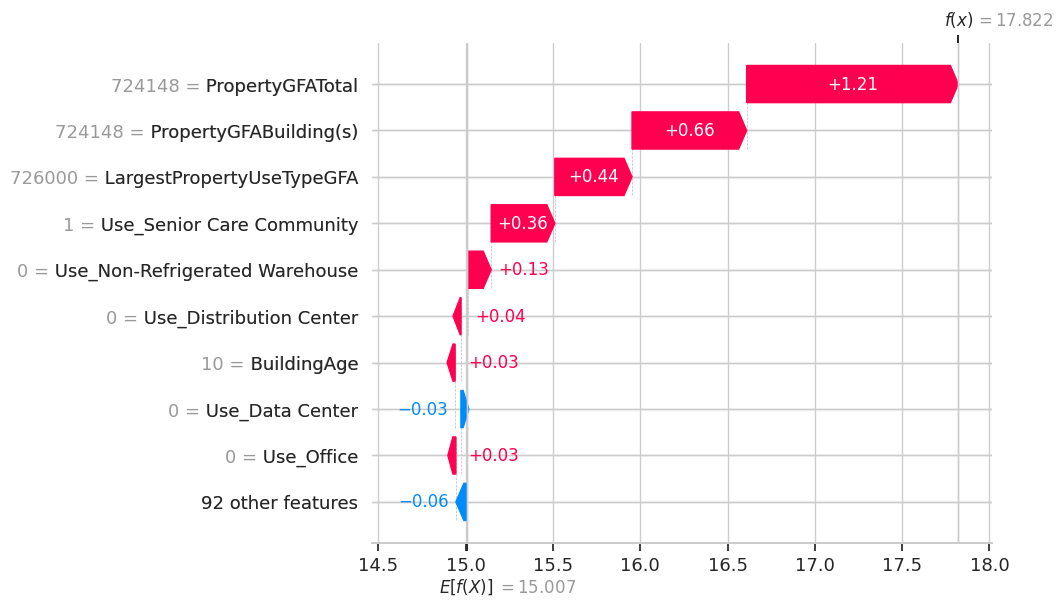

In [ ]:
# 1) forte consommation prédite
plot_local_shap(idx_high, "Bâtiment à forte consommation prédite")

Ce diagramme *waterfall* montre comment le modèle construit une **prédiction très élevée de consommation énergétique** pour ce bâtiment, en partant d'une valeur moyenne de référence et en ajoutant successivement les contributions des variables les plus influentes.

<br>

1. **Surfaces : facteur explicatif dominant**

La prédiction élevée est avant tout expliquée par les **caractéristiques de surface**, qui constituent l'essentiel de la contribution positive :
- La **surface totale du site** est le facteur le plus déterminant et explique à elle seule une large part de l'augmentation de la prédiction.
- La **surface bâtie** et la **surface associée à l'usage principal** renforcent fortement cet effet.

Ces contributions s'additionnent et traduisent une **relation quasi monotone entre taille du bâtiment et consommation énergétique**, ce qui est **pleinement cohérent avec les connaissances métier**.

<br>

2. **Effet amplificateur du type d'usage**

L'activation de l'usage "**Senior Care Community**" contribue également de manière significative à l'augmentation de la prédiction.

Cela indique que, **à surface comparable**, ce type de bâtiment présente des **besoins énergétiques structurellement plus élevés**, probablement liés à :
- une occupation continue,
- des exigences de confort strictes,
- et des équipements spécifiques.

<br>

3. **Contributions secondaires et ajustements fins**

Les autres variables jouent un rôle plus modéré :
- L'âge du bâtiment a un **impact positif faible**, suggérant un effet marginal comparé aux surfaces.
- L'absence de certains usages très énergivores (par exemple les data centers) exerce un **léger effet compensateur**, sans toutefois inverser la tendance globale.
- Les nombreuses autres variables non affichées ont un effet cumulé faible, ce qui indique que la prédiction repose principalement sur quelques facteurs clés.

<br>

4. **Lecture globale et cohérence du raisonnement**

Dans ce cas, le modèle **surestime la consommation réelle**, comme l'indique l'erreur absolue élevée.  
Cette surestimation s'explique par la **combinaison de plusieurs facteurs fortement pénalisants** :
- un bâtiment de **très grande taille**,
- une **concentration importante de surface sur l'usage principal**,
- un **usage associé à une forte intensité énergétique**.

Le raisonnement du modèle reste toutefois **cohérent et interprétable**, ce qui suggère que l'erreur provient davantage d'un **profil atypique du bâtiment** que d'un comportement erratique du modèle.

<font size="4"><b>Bâtiment à faible consommation prédite</b></font>

Bâtiment à faible consommation prédite — index=573 | prédiction=426,995 | vrai=511,797 | erreur_abs=84,803


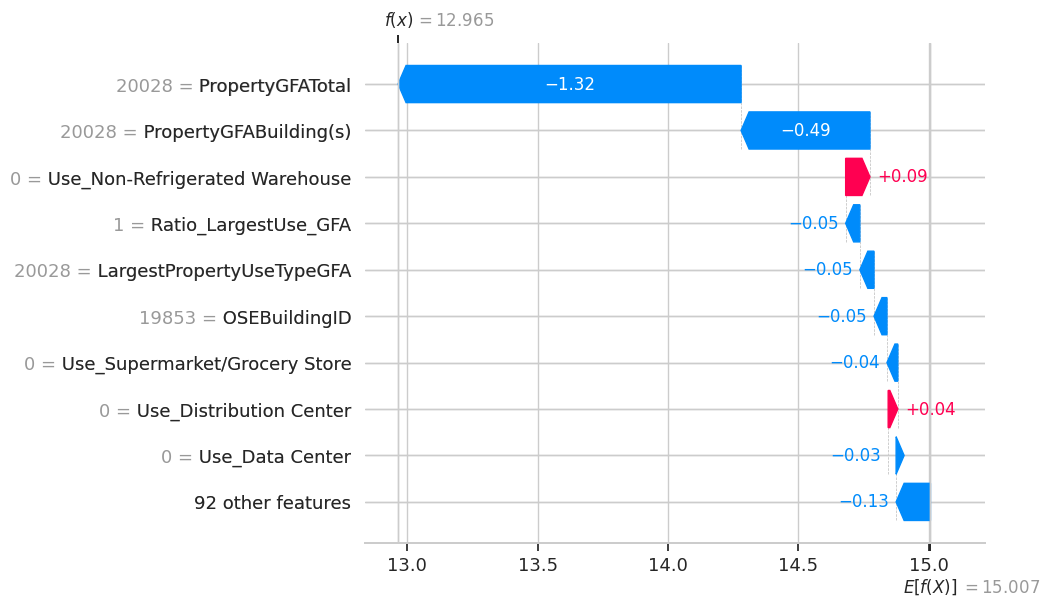

In [ ]:
# 2) faible consommation prédite
plot_local_shap(idx_low, "Bâtiment à faible consommation prédite")

Ce diagramme *waterfall* illustre les facteurs qui conduisent le modèle à prédire une **consommation énergétique très inférieure à la moyenne**, en partant de la valeur de référence globale et en appliquant successivement les contributions des variables propres à ce bâtiment.

<br>

1. **Faible surface : déterminant principal de la prédiction**

La **petite taille** du bâtiment constitue de loin le facteur explicatif dominant :
- La **surface totale du site** génère la contribution négative la plus importante, réduisant fortement la consommation prédite.
- La **surface bâtie** renforce cet effet, confirmant que le modèle associe directement **faible gabarit et faible consommation énergétique**.

Ces deux variables expliquent l'essentiel de l'écart par rapport à la consommation moyenne des bâtiments du jeu de données.

<br>

2. **Usage principal concentré et peu énergivore**

La présence d'un **ratio d'usage principal élevé** contribue également à diminuer la prédiction.

Cette configuration traduit un bâtiment dont la surface est **majoritairement dédiée à un seul usage**, ce qui est souvent associé à des **profils d'exploitation simples** et à une consommation énergétique plus contenue.

La **surface de l'usage principal**, elle aussi relativement faible, va dans le même sens et accentue cet effet.

<br>

3. **Absence d'usages fortement consommateurs**

Les variables liées aux usages spécifiques confirment ce profil sobre :

- L'absence de **data center**, de **supermarché** ou d'autres activités énergivores exerce des **effets négatifs modérés** sur la prédiction.
- Quelques usages absents produisent de légères contributions positives, mais celles-ci restent marginales face à l'impact structurant des surfaces.

<br>

4. **Lecture globale et cohérence du raisonnement**

La prédiction basse résulte donc principalement d'une **combinaison simple et cohérente de facteurs structurels** :
- un bâtiment de **petite taille**,
- une **structure d'usage concentrée**,
- l'absence d'activités à forte intensité énergétique.

L'erreur absolue observée reste relativement **limitée au regard des ordres de grandeur**, ce qui indique que le modèle parvient à **bien généraliser sur ce type de bâtiment standard** à faible consommation.

Ce cas illustre un **profil "sobre" typique**, pour lequel le raisonnement du modèle est **stable, interprétable et aligné avec les attentes métier**.

<font size="4"><b>Cas atypique (plus grande erreur)</b></font>

Bâtiment cas atypique (plus grande erreur) — index=270 | prédiction=41,031,551 | vrai=131,373,880 | erreur_abs=90,342,329


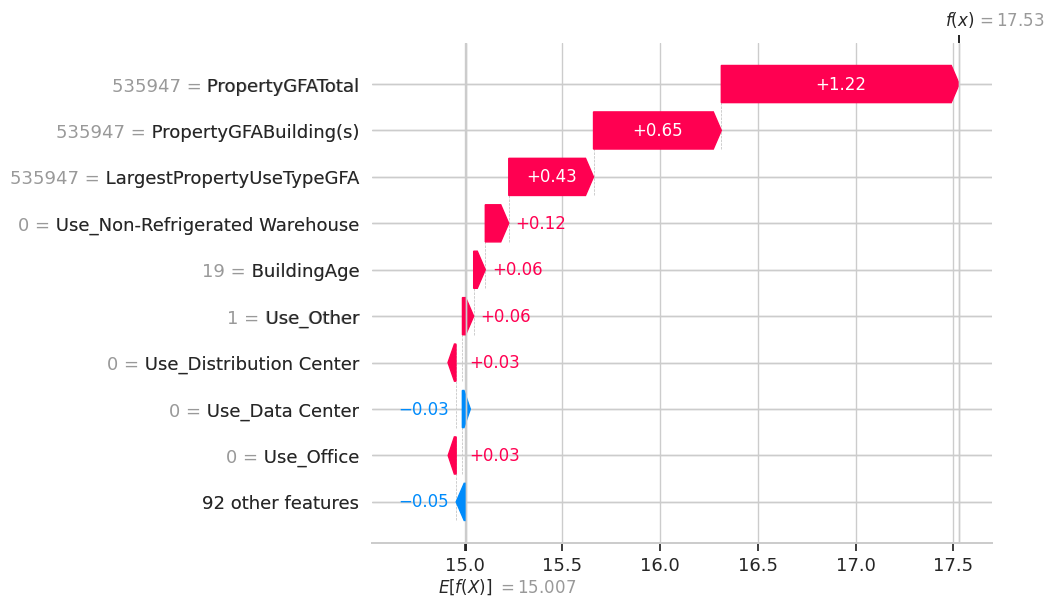

In [ ]:
# 3) atypique / intermédiaire
plot_local_shap(idx_weird, f"Bâtiment {weird_label}")

Ce diagramme *waterfall* met en évidence un cas pour lequel la **prédiction du modèle est très éloignée de la valeur réelle**, malgré un raisonnement interne qui reste cohérent au regard des variables disponibles.

<br>

1. **Un profil structurel proche d'un bâtiment très consommateur**

Comme pour le bâtiment à forte consommation prédite, le modèle s'appuie fortement sur des **variables de surface élevées** :
- La **surface totale du site** constitue la contribution positive principale, augmentant fortement la prédiction.
- La **surface bâtie** et la **surface de l'usage principal** renforcent ce signal, conduisant le modèle à classer ce bâtiment parmi les **grands bâtiments énergivores**.

Sur la base de ces seules informations structurelles, la prédiction élevée est donc **logiquement justifiée** du point de vue du modèle.

<br>

2. **Variables d'usage et d'âge : effets secondaires mais cohérents**

Les autres contributions restent d'ampleur plus limitée :
- L'**âge du bâtiment** apporte une contribution positive modérée, suggérant une performance énergétique potentiellement moins optimale.
- La présence de l'usage `Use_Other` joue également légèrement à la hausse, traduisant un **profil d'usage peu standard**, difficile à caractériser finement.
- L'absence d'usages très énergivores comme les **data centers** ou certains centres logistiques produit des contributions négatives modestes, insuffisantes pour compenser l'effet massif des surfaces.

<br>

3. **Origine probable de l'erreur importante**

Malgré un raisonnement interne cohérent, la **consommation réelle observée est très largement supérieure à la prédiction**, ce qui suggère que :
- certaines **caractéristiques déterminantes ne sont pas capturées par les variables disponibles** (intensité d'exploitation, équipements spécifiques, fonctionnement 24/7, process industriels, etc.) ;
- le bâtiment présente un **profil d'usage atypique** au regard des catégories encodées ;
- la relation entre surface et consommation est ici **non proportionnelle**, ce qui dépasse les capacités explicatives du modèle dans ce cas précis.

<br>

4. **Enseignements méthodologiques**

Ce cas illustre une limite classique des modèles globaux :
- le modèle **raisonne correctement à partir des features connues** ;
- mais il ne peut expliquer des **comportements extrêmes** lorsqu'ils reposent sur des facteurs non observés ou insuffisamment décrits.

L'erreur élevée ne traduit donc pas une incohérence du modèle, mais plutôt la présence de **bâtiments atypiques difficilement prévisibles** à partir des seules variables structurelles et d'usage standardisées.

<br>

5. **Conclusion locale**

Ce cas atypique confirme que :
- les surfaces **dominent fortement le raisonnement du modèle** ;
- certaines consommations exceptionnelles ne peuvent être correctement estimées sans **informations plus fines sur l'exploitation réelle** du bâtiment.

Il justifie pleinement l'usage d'une **analyse SHAP locale** pour identifier les situations où les prédictions doivent être interprétées avec prudence, notamment dans un contexte opérationnel ou décisionnel.

## 2.6. Limites et précautions d'interprétation

Les analyses d'importance globale et locale menées à l'aide de SHAP apportent une **transparence essentielle** sur le fonctionnement du modèle final. Toutefois, ces résultats doivent être interprétés avec **prudence**, en tenant compte de plusieurs limites inhérentes à l'approche.

<br>

1. **SHAP décrit le raisonnement du modèle, pas une relation causale**

Les valeurs SHAP indiquent **comment le modèle utilise les variables pour produire une prédiction**, mais elles ne traduisent **en aucun cas une relation de causalité réelle** entre une caractéristique et la consommation énergétique.

Ainsi :
- une variable fortement contributive n'est pas nécessairement un levier d'action direct ;
- certaines importances peuvent refléter des **corrélations indirectes** ou des effets de structure présents dans les données.

→ Cette distinction est essentielle pour éviter toute **sur-interprétation métier** des résultats.

<br>

2. **Forte dépendance à la qualité et à la représentativité des features**

Les explications fournies par SHAP sont **strictement conditionnées par les variables disponibles** dans le jeu de données :
> si une caractéristique déterminante n'est pas mesurée (intensité d'usage réel, équipements spécifiques, horaires d'exploitation, etc.), le modèle ne peut ni l'exploiter, ni l'expliquer.

Cela est particulièrement visible dans les **cas atypiques**, où le modèle raisonne de manière cohérente mais reste incapable d'anticiper des consommations extrêmes non décrites par les features.

<br>

3. **Sensibilité aux transformations et à la complexité des variables**

L'interprétation des valeurs SHAP dépend également des **transformations appliquées aux données** :
- l'utilisation d'une cible transformée (`log1p`) modifie l'échelle d'interprétation des contributions ;
- des variables agrégées ou abstraites (ratios, encodages catégoriels) rendent parfois l'analyse moins intuitive.

Il est donc important de :
- toujours replacer les contributions SHAP dans leur **contexte de modélisation** ;
- éviter les conclusions hâtives sur l'impact réel d'une variable sans analyse complémentaire.

<br>

4. **Importance globale vs importance locale**

Enfin, il convient de rappeler qu'une variable :
- peut être **peu importante globalement**,
- tout en étant **déterminante localement** pour certains bâtiments spécifiques.

Les analyses globale et locale sont donc **complémentaires** :
- la première permet de comprendre la logique générale du modèle ;
- la seconde éclaire des décisions individuelles, parfois atypiques.

<br>

<font size="4"><b>Conclusion</b></font>

Cette section met en évidence que les outils d'explicabilité comme SHAP sont **indispensables pour comprendre et justifier un modèle**, mais qu'ils doivent être utilisés avec **discernement**.

Ils constituent un **outil d'aide à l'interprétation**, et non une preuve causale, et doivent toujours être croisés avec :
- la connaissance métier,
- la qualité des données,
- et les limites structurelles du modèle.

Cette prise de recul est essentielle pour garantir une **utilisation responsable et pertinente** des modèles prédictifs dans un contexte réel.

## 2.7. Conclusion de l'étape 2

Cette étape a permis d'apporter une **lecture claire et approfondie du modèle final**, tant à l'échelle globale qu'à l'échelle individuelle.

Les analyses d'importance globale (spécifique au modèle et modèle-agnostique) montrent que la **consommation énergétique est principalement expliquée par des caractéristiques structurelles**, en particulier :
- la surface totale et la surface bâtie,
- la répartition des usages principaux,
- certains usages spécifiques à forte intensité énergétique.

Les analyses SHAP locales confirment cette hiérarchie tout en mettant en évidence la **variabilité des mécanismes explicatifs selon les bâtiments**, notamment dans les cas de consommations très élevées, très faibles ou atypiques. Le modèle adopte ainsi un raisonnement cohérent, combinant taille, structure et usage pour ajuster ses prédictions.

La cohérence observée entre :
- les performances globales du modèle,
- les importances de variables,
- et les explications locales,

renforce la **fiabilité et la crédibilité du modèle**, qui devient désormais **interprétable et justifiable auprès de parties prenantes non techniques**.

Cette étape marque une transition naturelle vers la suite du projet, qui se concentrera sur l'**analyse de l'influence de l'`ENERGYSTARScore`**, variable jusqu'ici mise de côté. L'objectif sera d'**évaluer son apport réel au modèle**, tant en termes de performance que d'interprétabilité, afin de déterminer s'il constitue un levier pertinent pour améliorer la prédiction de la consommation énergétique.

# 3. Analyse de l'influence de l'EnergyStarScore

## 3.0. Introduction et rappel du contexte

Jusqu'à présent, la variable `ENERGYSTARScore` a volontairement été **mise de côté** lors des phases de modélisation. Ce choix était motivé par sa nature particulière : il s'agit d'un **score synthétique**, potentiellement construit à partir d'informations proches de la consommation énergétique elle-même, ce qui pouvait introduire un **risque de fuite d'information (data leakage)**.

À ce stade du projet, le modèle final (Gradient Boosting optimisé) étant stabilisé et interprété, il devient pertinent de tester explicitement l'impact de cette variable.

L'objectif de cette section est donc de :
- mesurer l'influence réelle de `ENERGYSTARScore` sur les performances du modèle ;
- comparer les résultats **avec et sans cette variable**, dans un cadre expérimental strictement identique ;
- déterminer si son intégration améliore réellement la capacité prédictive du modèle, ou si son apport reste marginal au regard des risques méthodologiques.

Cette analyse permettra de conclure de manière argumentée sur la pertinence de conserver ou non `ENERGYSTARScore` dans une version opérationnelle du modèle.

## 3.1. Construction du sous-ensemble avec `ENERGYSTARScore`

Afin d'évaluer proprement l'impact de `ENERGYSTARScore`, il est nécessaire de :
- Ne conserver que les individus déjà utilisés dans `X_train` et `X_test`
- Éliminer les observations pour lesquelles `ENERGYSTARScore` est manquant
- Garantir l'alignement via `OSEBuildingID`

Cela permet :
- d'éviter toute fuite d'information,
- de comparer strictement les performances avec et sans la variable,
- de conserver la cohérence des splits train/test.


In [ ]:
# 1) Mapping OSEBuildingID -> ENERGYSTARScore depuis df initial
energy_map = df.set_index("OSEBuildingID")["ENERGYSTARScore"]

# 2) Ajout du score
X_train_es = X_train.copy()
X_test_es  = X_test.copy()

X_train_es["ENERGYSTARScore"] = X_train_es["OSEBuildingID"].map(energy_map)
X_test_es["ENERGYSTARScore"]  = X_test_es["OSEBuildingID"].map(energy_map)

# 3) Filtrage : uniquement les observations où le score est présent
mask_train = X_train_es["ENERGYSTARScore"].notna()
mask_test  = X_test_es["ENERGYSTARScore"].notna()

X_train_es = X_train_es.loc[mask_train]
X_test_es  = X_test_es.loc[mask_test]

# 4) Alignement y
y_train_es = y_train.loc[X_train_es.index]
y_test_es  = y_test.loc[X_test_es.index]

print("Train subset:", X_train_es.shape, " | y:", y_train_es.shape)
print("Test subset:", X_test_es.shape, " | y:", y_test_es.shape)

Train subset: (737, 102)  | y: (737,)
Test subset: (188, 102)  | y: (188,)


## 3.2. Comparaison du modèle avec et sans ENERGYSTARScore

**Objectif -** Mesurer rigoureusement l'impact de ENERGYSTARScore sur :
- la capacité explicative du modèle (R²),
- l'erreur moyenne (MAE),
- l'erreur globale (RMSE).

La comparaison est réalisée :
- sur **le même sous-ensemble d'individus**,
- avec **la même validation croisée**,
- et **le même modèle optimisé (Gradient Boosting)**.

Cela garantit une comparaison équitable.

### 3.2.1. Modèle sans ENERGYSTARScore

In [ ]:
X_train_no_es = X_train_es.drop(columns=["ENERGYSTARScore"], errors="ignore")

cv_no_es = cross_validate(
    best_gbr,
    X_train_no_es,
    y_train_es,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

results_no_es = {
    "Model": "Gradient Boosting (sans EnergyStarScore)",
    "R2_CV": np.mean(cv_no_es["test_r2"]),
    "MAE_CV": -np.mean(cv_no_es["test_mae"]),
    "RMSE_CV": np.sqrt(-np.mean(cv_no_es["test_mse"]))
}

### 3.2.2. Modèle avec ENERGYSTARScore

In [ ]:
cv_with_es = cross_validate(
    best_gbr,
    X_train_es,
    y_train_es,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

results_with_es = {
    "Model": "Gradient Boosting (avec EnergyStarScore)",
    "R2_CV": np.mean(cv_with_es["test_r2"]),
    "MAE_CV": -np.mean(cv_with_es["test_mae"]),
    "RMSE_CV": np.sqrt(-np.mean(cv_with_es["test_mse"]))
}

### 3.2.3. Comparaison des scores

In [ ]:
comparison_es = pd.DataFrame([results_no_es, results_with_es])
comparison_es

,Model,R2_CV,MAE_CV,RMSE_CV
0,Gradient Boosting (sans EnergyStarScore),0.77,0.45,0.60
1,Gradient Boosting (avec EnergyStarScore),0.87,0.32,0.45


L'ajout de la variable **ENERGYSTARScore** améliore très significativement les performances du modèle.

<br>

<font size="4"><b>Comparaison des performances</b></font>

- **Sans ENERGYSTARScore**
  - R² ≈ 0.77
  - MAE ≈ 0.45
  - RMSE ≈ 0.60

- **Avec ENERGYSTARScore**
  - R² ≈ 0.87
  - MAE ≈ 0.32
  - RMSE ≈ 0.45

L'amélioration est nette sur les trois métriques :
- Le **R² augmente fortement** (+0.10), ce qui signifie que le modèle explique une part beaucoup plus importante de la variance.
- Le **MAE diminue fortement**, indiquant des prédictions nettement plus proches des valeurs réelles en moyenne.
- Le **RMSE baisse également**, traduisant une meilleure maîtrise des erreurs importantes.

<br>

<font size="4"><b>Interprétation métier</b></font>

Cette amélioration confirme que **l'ENERGYSTARScore contient une information extrêmement importante sur la performance énergétique d'un bâtiment**.

Ce score synthétise déjà :
- l'efficacité énergétique relative du bâtiment,
- son positionnement par rapport à des bâtiments comparables,
- une partie de l'information structurelle et d'usage.

Autrement dit, il agit comme une **variable fortement corrélée à la cible**, capable d'expliquer une grande part de la consommation.

<br>

<font size="4"><b>Point de vigilance - Risque de fuite d'information</b></font>

Il convient toutefois de s'interroger sur la nature de cette variable :
> Si l'`ENERGYSTARScore` est calculé à partir d'indicateurs proches de la consommation énergétique réelle, alors son intégration peut introduire un **risque de data leakage partiel**, ou au minimum réduire l'intérêt prédictif du modèle dans un contexte opérationnel réel (si le score n'est pas toujours disponible).

L'usage de cette variable dépend donc du **contexte métier** :
- pertinente si le score est disponible au moment de la prédiction,
- problématique si l'objectif est de prédire la consommation avant toute évaluation énergétique.

<br>

<font size="4"><b>Conclusion</b></font>

L'`ENERGYSTARScore` est une variable **très fortement prédictive**.

Son intégration permet un gain de performance majeur, mais son utilisation doit être **justifiée par le cadre opérationnel du projet** afin d'éviter tout biais ou dépendance excessive à un indicateur déjà fortement lié à la cible.

# 4. Conclusion générale du notebook

Ce notebook avait pour objectif de construire un modèle prédictif robuste de la **consommation énergétique totale des bâtiments non résidentiels**, en suivant une démarche complète :
- nettoyage et structuration des données,
- feature engineering raisonné,
- comparaison de plusieurs familles de modèles,
- optimisation des hyperparamètres,
- analyse d'interprétabilité globale et locale,
- étude de l'impact d'une variable métier clé : ENERGYSTARScore.

<br>

<font size="4"><b>1. Performance du modèle retenu</b></font>

Après comparaison entre modèles linéaires et modèles d'ensemble :
- Le **Gradient Boosting** a été retenu comme modèle final.
- Son optimisation a permis d'obtenir des performances solides en validation croisée.
- L'évaluation sur jeu de test confirme une **capacité de généralisation satisfaisante**.

Le modèle capte efficacement :
- les effets de **taille du bâtiment**,
- la **répartition des usages**,
- certaines **spécificités structurelles**.

<br>

<font size="4"><b>2. Interprétabilité et compréhension du modèle</b></font>

L'analyse de la feature importance (méthode interne au modèle, permutation importance et SHAP) a permis de :
- identifier clairement les variables dominantes ;
- confirmer la cohérence métier des résultats ;
- expliquer individuellement des prédictions spécifiques.

Les analyses locales ont montré que :
- les surfaces jouent un rôle central,
- certains usages spécifiques modulent fortement la consommation,
- les erreurs importantes proviennent souvent de bâtiments atypiques.

Le modèle est donc **non seulement performant, mais également explicable**, ce qui constitue un point fort pour une utilisation réelle.

<br>

<font size="4"><b>3. Impact de l'ENERGYSTARScore</b></font>


L'ajout de la variable **ENERGYSTARScore** a entraîné une amélioration majeure des performances :
- augmentation significative du R²,
- baisse marquée des erreurs.

Cela confirme que ce score contient une information fortement impactante.

Cependant, son utilisation soulève une question stratégique :
- S'il est disponible au moment de la prédiction, il constitue un levier très puissant.
- S'il est dérivé de données proches de la cible, il peut réduire l'intérêt prédictif du modèle ou introduire une forme de dépendance.

Son intégration dépend donc du **cadre opérationnel et des contraintes métier**.

<br>

<font size="4"><b>4. Limites du modèle</b></font>

Plusieurs limites subsistent :
- Présence de bâtiments atypiques générant des erreurs importantes.
- Forte dépendance aux variables de surface.
- Sensibilité aux distributions asymétriques (nécessité d'une transformation de la cible).

Malgré cela, le modèle reste :
- robuste,
- cohérent,
- interprétable,
- et méthodologiquement solide.

<br>

<font size="4"><b>5. Perspectives</b></font>

Plusieurs pistes d'amélioration peuvent être envisagées :
- affinement supplémentaire des hyperparamètres ;
- segmentation des bâtiments par typologie ;
- modélisation spécifique des bâtiments extrêmes ;
- intégration de variables externes (climat, occupation réelle, équipements techniques).

<br>

___

<br>

<font size="4"><b>Bilan</b></font>

Ce notebook démontre :
- une démarche complète de modélisation supervisée ;
- une comparaison méthodique de plusieurs familles d'algorithmes ;
- une optimisation raisonnée ;
- une analyse d'interprétabilité globale et locale ;
- une réflexion critique sur les variables utilisées.

Le modèle final est **performant, explicable et cohérent d'un point de vue métier**, ce qui constitue une base solide pour un déploiement opérationnel.